# Cost Optimization

## Question

**탐지 성능이 높은 모델이 실제 운영에서도 가장 좋은 선택일까?**

## Objective

FN과 FP의 상대적 비용을 반영한 Total Cost를 기준으로
모델별 예상 손실을 비교하고 운영상 최적의 선택을 찾는다.

In [63]:
FN_cost = 1000
FP_cost = 50

In [ ]:
# elliptic envelope
cost_ee = []

thresholds = np.unique(score_ee_df["scaled_score"])

for t in thresholds:
    y_pred_t = (score_ee_df["scaled_score"] >= t).astype(int) # scores(=anomaly score임)가 threshold 이상이면 이상치

    tn, fp, fn, tp = confusion_matrix(score_ee_df["y_true"], y_pred_t).ravel()
    cost = (fn * FN_cost) + (fp * FP_cost)

    precision = precision_score(score_ee_df["y_true"], y_pred_t, zero_division = 0)
    recall = recall_score(score_ee_df["y_true"], y_pred_t, zero_division = 0)
    f1 = f1_score(score_ee_df["y_true"], y_pred_t, zero_division = 0)
    
    cost_ee.append({
        "threshold" : t
        , "tn" : tn
        , "fp" : fp
        , "fn" : fn
        , "tp" : tp
        , "precision" : precision
        , "recall" : recall
        , "f1" : f1
        , "cost" : cost
    })

In [ ]:
cost_ee_df = pd.DataFrame(cost_ee)
cost_ee_df.sort_values("cost").head(10)

In [39]:
cost_ee_df = pd.read_csv("cost_ee_df.csv")
cost_ee_df.tail()

,threshold,tn,fp,fn,tp,precision,recall,f1,cost
28419,7.424214,28424,8,5,25,0.757576,0.833333,0.793651,5400
28420,9.017933,28425,7,5,25,0.781250,0.833333,0.806452,5350
28421,10.914823,28426,6,5,25,0.806452,0.833333,0.819672,5300
28422,99.361377,28427,5,5,25,0.833333,0.833333,0.833333,5250
28423,100.000000,28428,4,5,25,0.862069,0.833333,0.847458,5200


In [66]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

=== ① 하이퍼파라미터 튜닝 단계 선정 지점 ===
threshold=99.36, F1=0.8333, Cost=5250

=== ② 비용함수 재탐색 최적 지점 (Cost 최소) ===
threshold=100.00, F1=0.8475, Cost=5200

=== 참고: 이 데이터 내 F1 진짜 최댓값 ===
threshold=100.00, F1=0.8475, Cost=5200


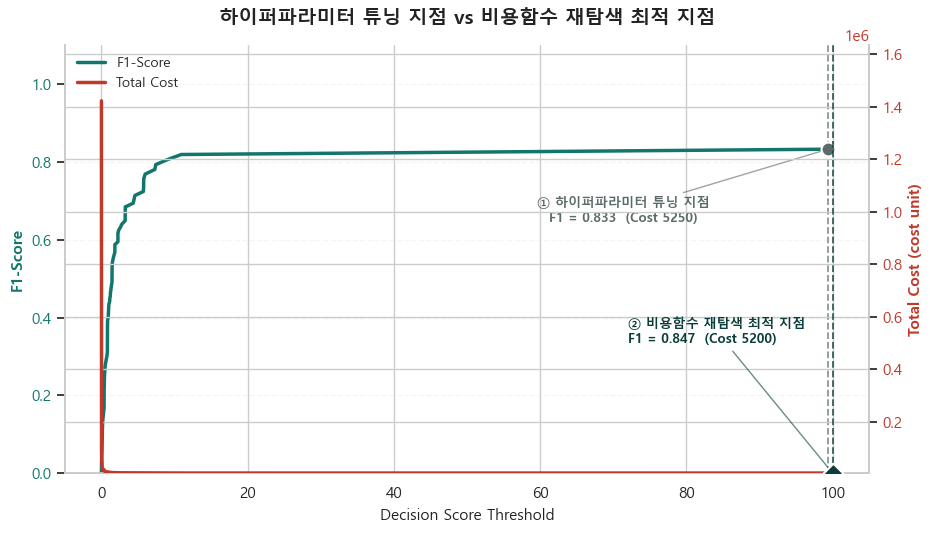

In [67]:
threshold = cost_ee_df["threshold"].values
f1_scores = cost_ee_df["f1"].values
cost_values = cost_ee_df["cost"].values

# ① 하이퍼파라미터 튜닝 단계에서 F1 기준으로 선정했던 지점
#    (contamination/support_fraction 그리드서치 결과, F1=0.8333)
# ------------------------------------------------------------
hp_tuning_row = cost_ee_df[np.isclose(cost_ee_df["threshold"], 99.361377, atol=1e-3)].iloc[0]
HP_THRESHOLD = hp_tuning_row["threshold"]
HP_F1 = hp_tuning_row["f1"]
HP_COST = hp_tuning_row["cost"]

# ------------------------------------------------------------
# ② 비용함수 재탐색 단계에서 Cost 기준으로 찾은 최종 최적 지점
#    (모든 decision score를 threshold 후보로 스캔 → Cost 최소)
# ------------------------------------------------------------
cost_optimal_row = cost_ee_df.loc[cost_ee_df["cost"].idxmin()]
COST_OPT_THRESHOLD = cost_optimal_row["threshold"]
COST_OPT_F1 = cost_optimal_row["f1"]
COST_OPT_COST = cost_optimal_row["cost"]

# 검증용 출력 — 두 지점이 실제로 다른지, F1 진짜 최댓값과 비교
print("=== ① 하이퍼파라미터 튜닝 단계 선정 지점 ===")
print(f"threshold={HP_THRESHOLD:.2f}, F1={HP_F1:.4f}, Cost={HP_COST:.0f}")
print("\n=== ② 비용함수 재탐색 최적 지점 (Cost 최소) ===")
print(f"threshold={COST_OPT_THRESHOLD:.2f}, F1={COST_OPT_F1:.4f}, Cost={COST_OPT_COST:.0f}")
print("\n=== 참고: 이 데이터 내 F1 진짜 최댓값 ===")
f1_max_row = cost_ee_df.loc[cost_ee_df["f1"].idxmax()]
print(f"threshold={f1_max_row['threshold']:.2f}, F1={f1_max_row['f1']:.4f}, Cost={f1_max_row['cost']:.0f}")


COLOR_F1 = "#12766D"
COLOR_COST = "#C0392B"
COLOR_HP = "#5B6B69"      # 하이퍼파라미터 튜닝 지점 (회색 계열 — '이전 단계')
COLOR_COST_OPT = "#0B3D3A"  # 비용함수 최적 지점 (진한 틸 — '최종 채택')
COLOR_BG = "#FFFFFF"
COLOR_GRID = "#E5E5E5"
COLOR_TEXT = "#222222"

# 그래프 그리기 (이중 Y축 + 두 단계 지점 표시)
# ============================================================
fig, ax1 = plt.subplots(figsize=(9.5, 5.5), facecolor=COLOR_BG)
ax1.set_facecolor(COLOR_BG)

# 왼쪽 축: F1-Score 곡선
ax1.plot(threshold, f1_scores, color=COLOR_F1, linewidth=2.5, label="F1-Score", zorder=3)
ax1.set_xlabel("Decision Score Threshold", fontsize=11, color=COLOR_TEXT)
ax1.set_ylabel("F1-Score", fontsize=11, color=COLOR_F1, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=COLOR_F1)
ax1.set_ylim(0, max(f1_scores) * 1.3)
ax1.grid(axis="y", linestyle="--", alpha=0.35, color=COLOR_GRID, zorder=0)

# 오른쪽 축: Total Cost 곡선
ax2 = ax1.twinx()
ax2.plot(threshold, cost_values, color=COLOR_COST, linewidth=2.5, label="Total Cost", zorder=3)
ax2.set_ylabel("Total Cost (cost unit)", fontsize=11, color=COLOR_COST, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=COLOR_COST)
ax2.set_ylim(min(cost_values) * 0.85, max(cost_values) * 1.15)

# ------------------------------------------------------------
# ① 하이퍼파라미터 튜닝 단계 지점 표시 (F1 곡선 위)
# ------------------------------------------------------------
ax1.axvline(HP_THRESHOLD, color=COLOR_HP, linestyle="--", linewidth=1.3, alpha=0.7, zorder=2)
ax1.scatter([HP_THRESHOLD], [HP_F1], color=COLOR_HP, s=100, zorder=5,
            edgecolor="white", linewidth=1.5, marker="o")
ax1.annotate(
    f"① 하이퍼파라미터 튜닝 지점\nF1 = {HP_F1:.3f}  (Cost {HP_COST:.0f})",
    xy=(HP_THRESHOLD, HP_F1),
    xytext=(HP_THRESHOLD - (threshold.max() - threshold.min()) * 0.28, HP_F1 - max(f1_scores) * 0.22),
    fontsize=9.5, fontweight="bold", color=COLOR_HP, ha="center",
    arrowprops=dict(arrowstyle="-", color=COLOR_HP, lw=1, alpha=0.6),
)

# ------------------------------------------------------------
# ② 비용함수 재탐색 최적 지점 표시 (Cost 곡선 위)
# ------------------------------------------------------------
ax2.axvline(COST_OPT_THRESHOLD, color=COLOR_COST_OPT, linestyle="--", linewidth=1.3, alpha=0.8, zorder=2)
ax2.scatter([COST_OPT_THRESHOLD], [COST_OPT_COST], color=COLOR_COST_OPT, s=100, zorder=5,
            edgecolor="white", linewidth=1.5, marker="D")
ax2.annotate(
    f"② 비용함수 재탐색 최적 지점\nF1 = {COST_OPT_F1:.3f}  (Cost {COST_OPT_COST:.0f})",
    xy=(COST_OPT_THRESHOLD, COST_OPT_COST),
    xytext=(COST_OPT_THRESHOLD - (threshold.max() - threshold.min()) * 0.28,
            COST_OPT_COST + (max(cost_values) - min(cost_values)) * 0.35),
    fontsize=9.5, fontweight="bold", color=COLOR_COST_OPT, ha="left",
    arrowprops=dict(arrowstyle="-", color=COLOR_COST_OPT, lw=1, alpha=0.6),
)

# 범례
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10, frameon=False)

for spine in ["top"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.title("하이퍼파라미터 튜닝 지점 vs 비용함수 재탐색 최적 지점", fontsize=14, fontweight="bold", color=COLOR_TEXT, pad=15)
plt.tight_layout()

#plt.savefig("f1_vs_cost_threshold.png", dpi=300, bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

In [40]:
best_cost_row = cost_ee_df.sort_values(
    ["cost", "f1", "recall"],
    ascending=[True, False, False]
).iloc[0]
best_cost_row
# 1순위 Cost, 2순위 F1, 3순위 recall

threshold      100.000000
tn           28428.000000
fp               4.000000
fn               5.000000
tp              25.000000
precision        0.862069
recall           0.833333
f1               0.847458
cost          5200.000000
Name: 28423, dtype: float64


[Final EE with Best Threshold]
Precision:  0.8621
Recall:  0.8333
F1-score:  0.8475

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.86      0.83      0.85        30

    accuracy                           1.00     28462
   macro avg       0.93      0.92      0.92     28462
weighted avg       1.00      1.00      1.00     28462



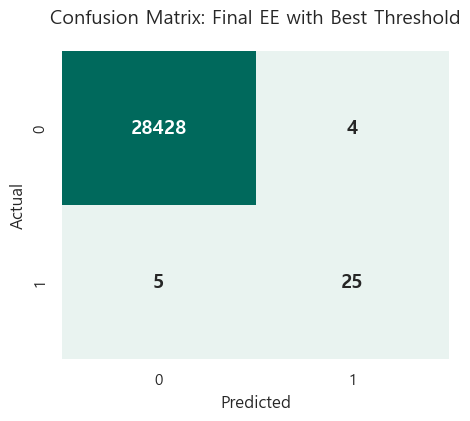

{'model': 'Final EE with Best Threshold',
 'precision': 0.8620689655172413,
 'recall': 0.8333333333333334,
 'f1': 0.847457627118644}

In [41]:
best_threshold = best_cost_row["threshold"]
best_pred = (score_ee_df["scaled_score"] >= best_threshold).astype(int)

evaluate_model(score_ee_df["y_true"], best_pred, "Final EE with Best Threshold")

In [59]:
# 1. Anomaly Score 계산 (이상치일수록 높은 양수)
if_scores = best_if.decision_function(val_x)
if_anomaly_scores = -if_scores

score_if_df = pd.DataFrame({"y_true" : val_y.values, "scores" : if_anomaly_scores})

# 2. 이상치 스케일을 통제하기 위해 상위 99.9% 지점을 max_val로 설정
min_val = score_if_df["scores"].min()
max_val = score_if_df["scores"].quantile(0.999)  # 상위 0.1% 이상치는 100점으로 고정 # 1%로 하니까 성능이 매우 안좋게 나옴

# 3. Min-Max Scaling 적용 후 0~100 사이로 캡핑(np.clip)
score_if_df["scaled_score"] = (
    (score_if_df["scores"] - min_val) / (max_val - min_val) * 100
)
score_if_df["scaled_score"] = score_if_df["scaled_score"].clip(0, 100)

score_if_df.head()

,y_true,scores,scaled_score
0,0,-0.207946,5.728217
1,0,-0.177602,16.549113
2,0,-0.194832,10.404556
3,0,-0.188621,12.619411
4,0,-0.140140,29.907688


In [60]:
# Isolation Forest
FN_cost = 1000
FP_cost = 50

cost_if = []

thresholds = np.unique(score_if_df["scaled_score"])

for t in thresholds:
    y_pred_t = (score_if_df["scaled_score"] >= t).astype(int) # scaled_scores

    tn, fp, fn, tp = confusion_matrix(score_if_df["y_true"], y_pred_t).ravel()
    cost = (fn * FN_cost) + (fp * FP_cost)

    precision = precision_score(score_if_df["y_true"], y_pred_t, zero_division = 0)
    recall = recall_score(score_if_df["y_true"], y_pred_t, zero_division = 0)
    f1 = f1_score(score_if_df["y_true"], y_pred_t, zero_division = 0)
    
    cost_if.append({
        "threshold" : t
        , "tn" : tn
        , "fp" : fp
        , "fn" : fn
        , "tp" : tp
        , "precision" : precision
        , "recall" : recall
        , "f1" : f1
        , "cost" : cost
    })

In [61]:
cost_if_df = pd.DataFrame(cost_if)
cost_if_df.sort_values("cost").head(10)

,threshold,tn,fp,fn,tp,precision,recall,f1,cost
28309,77.151548,28404,28,13,17,0.377778,0.566667,0.453333,14400
28308,76.982700,28403,29,13,17,0.369565,0.566667,0.447368,14450
28307,76.030338,28402,30,13,17,0.361702,0.566667,0.441558,14500
28306,75.572091,28401,31,13,17,0.354167,0.566667,0.435897,14550
28305,75.486230,28400,32,13,17,0.346939,0.566667,0.430380,14600
28304,75.435800,28399,33,13,17,0.340000,0.566667,0.425000,14650
28303,75.216889,28398,34,13,17,0.333333,0.566667,0.419753,14700
28302,74.981695,28397,35,13,17,0.326923,0.566667,0.414634,14750
28301,74.238543,28396,36,13,17,0.320755,0.566667,0.409639,14800
28300,72.535453,28395,37,13,17,0.314815,0.566667,0.404762,14850


In [62]:
cost_if_df.to_csv("cost_if_df.csv",index=False,encoding="utf-8-sig")

In [63]:
cost_if_df = pd.read_csv("cost_if_df.csv")

In [64]:
if_cost_row = cost_if_df.sort_values(
    ["cost", "f1", "recall"],
    ascending=[True, False, False]
).iloc[0]
if_cost_row

threshold       77.151548
tn           28404.000000
fp              28.000000
fn              13.000000
tp              17.000000
precision        0.377778
recall           0.566667
f1               0.453333
cost         14400.000000
Name: 28309, dtype: float64


[Final IF with Best Threshold]
Precision:  0.3778
Recall:  0.5667
F1-score:  0.4533

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.38      0.57      0.45        30

    accuracy                           1.00     28462
   macro avg       0.69      0.78      0.73     28462
weighted avg       1.00      1.00      1.00     28462



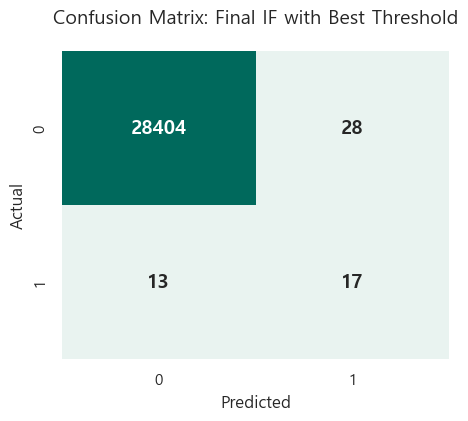

{'model': 'Final IF with Best Threshold',
 'precision': 0.37777777777777777,
 'recall': 0.5666666666666667,
 'f1': 0.4533333333333333}

In [65]:
if_best_threshold = if_cost_row["threshold"]
if_best_pred = (score_if_df["scaled_score"] >= if_best_threshold).astype(int)

evaluate_model(score_if_df["y_true"], if_best_pred, "Final IF with Best Threshold")